In [1]:
# -*- coding: utf-8 -*-
#  Copyright 2024 United Kingdom Research and Innovation
#
#  Licensed under the Apache License, Version 2.0 (the "License");
#  you may not use this file except in compliance with the License.
#  You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
#  Unless required by applicable law or agreed to in writing, software
#  distributed under the License is distributed on an "AS IS" BASIS,
#  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#  See the License for the specific language governing permissions and
#  limitations under the License.
#
#  Authored by:    Rasmia Kulan (UKRI-STFC)
#                  Laura Murgatroyd (UKRI-STFC)

# PDHG-TV Applied to Reduced Data

This notebook demonstrates applying PDHG-TV - an iterative reconstruction algorithm - to data with reduced exposure time and number of projections. The results are compared to FBP of the full data, FBP of reduced data and SIRT of the reduced data.

### Choice of Algorithm: PDHG-TV
We will run iterative reconstruction on our reduced dataset with an aim to produce a more accurate reconstruction than with FBP.

Our choice of algorithm is Explicit PDHG-TV, where we will use PDHG to solve:
$$
u^{*} =\underset{u}{\operatorname{argmin}} \frac{1}{2} \| \mathcal{A} u - g\|^{2} + \alpha\,\mathrm{TV}(u).
$$

Which has a data-fidelity term, plus a regularisation term (TV).


$g$ is the Acquisition data obtained from the detector.

$\mathcal{A}$ is the projection operator ( Radon transform ) that maps from an image-space to an acquisition space.

$u$ is the solution - the reconstruction.

$\alpha$ is the regularising parameter that measures the trade-off between the data fidelity and regularising terms.


TV (Total Variation) is a regulariser which enforces smooth regions with sharp boundaries, and we know that our sample has these - for example homogenous material inside the rods with sharp boundaries around their edges.

This algorithm is available in Mantid Imaging.

Imports:

In [2]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np

from cil.optimisation.algorithms import PDHG
from cil.optimisation.functions import IndicatorBox
from cil.plugins.astra import ProjectionOperator
from cil.processors import Slicer
from cil.utilities.display import show1D, show2D

from data_io.alum_cyl_io import read_processed_data
from recon.weighted_fbp import run_weighted_fbp_parallel
from utils.pdhg import setup_explicit_TV
warnings.filterwarnings("ignore")

In [3]:
exp_1min_angles_840 = read_processed_data(exposure_time=60, num_angles=840)
exp_30s_angles_210 = read_processed_data(exposure_time=30, num_angles=210)

processed_data_dict = {'FBP [1 min, 840 angles]': exp_1min_angles_840, 'FBP [30s, 210 angles]': exp_30s_angles_210}

If you have any trouble loading the data in the above cell, please see the start of the [Angles_vs_Exposure_01_Introduction_to_Aluminium_Cylinder.ipynb](Angles_vs_Exposure_01_Introduction_to_Aluminium_Cylinder.ipynb) notebook.

### Reconstruct with FBP

In [4]:
A = (245, 246)
B = (623, 624)
C = (987, 988)
sliceA_slicer = Slicer(roi={'vertical': A})
sliceB_slicer = Slicer(roi={'vertical': B})
sliceC_slicer = Slicer(roi={'vertical': C})

slicers = [sliceA_slicer, sliceB_slicer, sliceC_slicer]
slicer_ranges = [A, B, C]

In [5]:
sliced_recon_dict = {key:[] for key in processed_data_dict.keys()}
sliced_preproc_data_dict = {key:[] for key in processed_data_dict.keys()}


for key, data in processed_data_dict.items():
    for r in slicer_ranges:
        cor = data.geometry.get_centre_of_rotation(distance_units='pixels')
        vertical = r[0]
        vertical_offset = -data.shape[1]/2 + vertical
        angle = cor['angle'][0]
        offset_at_centre = cor['offset'][0]
        new_offset = offset_at_centre + vertical_offset * np.tan(angle)

        data_1 = data.copy()
        data_1.geometry.set_centre_of_rotation(0)
        data_1_slice = Slicer(roi={'vertical': r})(data_1)
        
        data_1_slice.geometry.set_centre_of_rotation(new_offset, distance_units='pixels', angle=angle)
        s = data_1_slice
        recon = run_weighted_fbp_parallel(data_1_slice)


        sliced_recon_dict[key].append(recon)
        sliced_preproc_data_dict[key].append(data_1_slice)


In [29]:
alpha=2.5e-5

PDHG_nn_algos = {alpha: [] for alpha in [alpha]}


for i in range(3):
        ad = sliced_preproc_data_dict['FBP [30s, 210 angles]'][i]
        ag = ad.geometry
        ig = ag.get_ImageGeometry()
        A = ProjectionOperator(ig, ag, device="gpu")

        K, F = setup_explicit_TV(A, ad, omega=1, alpha=alpha)
        normK = K.norm()
        sigma = 1 # in CIL is 1/normK by default
        tau = 1 / (sigma * normK**2) # in CIL is 1/normK by default
        G = IndicatorBox(lower=0)

        myPDHG_explicit_NN = PDHG(f=F, g=G,
                        sigma=sigma,
                        tau=tau,
                        operator=K,
                        update_objective_interval=10)
        PDHG_nn_algos[alpha].append(myPDHG_explicit_NN)

We run PDHG-TV on 3 slices of interest. Ideally it would be run on the full dataset but this was too time consuming:

In [30]:
iteration_nums = 10000
for pdhg in PDHG_nn_algos[alpha]:
    pdhg.run(iteration_nums)

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

These plots show the convergence of the algorithm for each slice. We look for the objective to converge, but also aim for a dual gap close to 0:

Final difference in objective value: -0.0001220028629376202
Final dual gap value: 0.1657994178710851


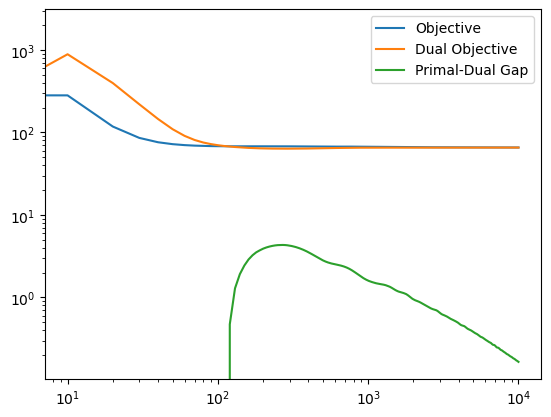

Final difference in objective value: -0.002209078065178005
Final dual gap value: 6.855932322599244


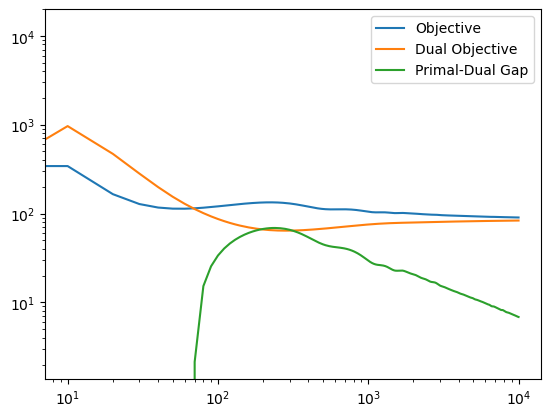

Final difference in objective value: -0.002900305781523116
Final dual gap value: 6.033367015471882


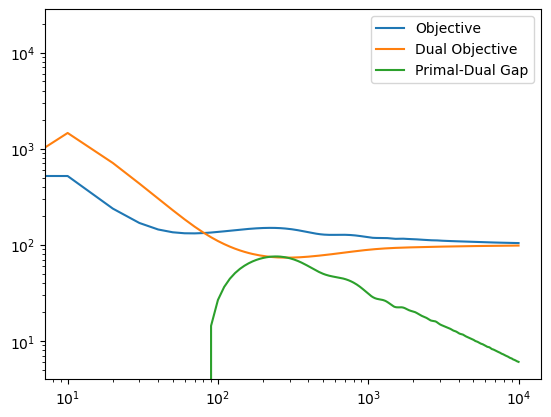

In [31]:
for pdhg_algo in PDHG_nn_algos[alpha]:
    print("Final difference in objective value:", pdhg_algo.objective[-1] - pdhg_algo.objective[-2])
    print("Final dual gap value:", pdhg_algo.primal_dual_gap[-1])
    plt.loglog(pdhg_algo.iterations, pdhg_algo.objective)
    plt.loglog(pdhg_algo.iterations, pdhg_algo.dual_objective)
    plt.loglog(pdhg_algo.iterations, pdhg_algo.primal_dual_gap)
    plt.legend(['Objective', 'Dual Objective', 'Primal-Dual Gap'])
    plt.show()
    

The difference in objective value does not get as small as we would like, but we found this to be the case with 1000s more iterations.

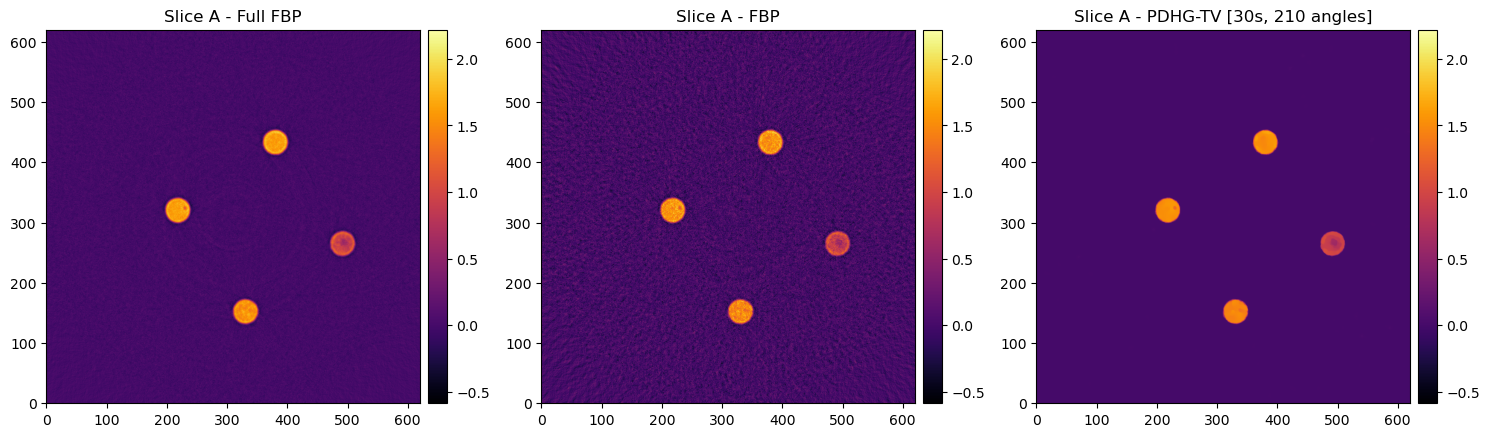

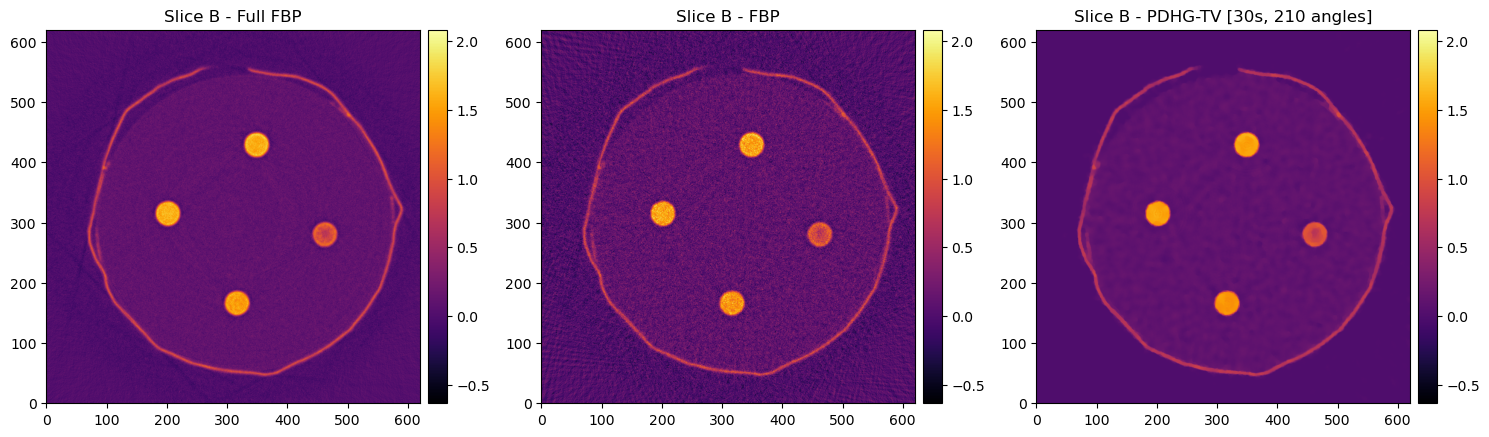

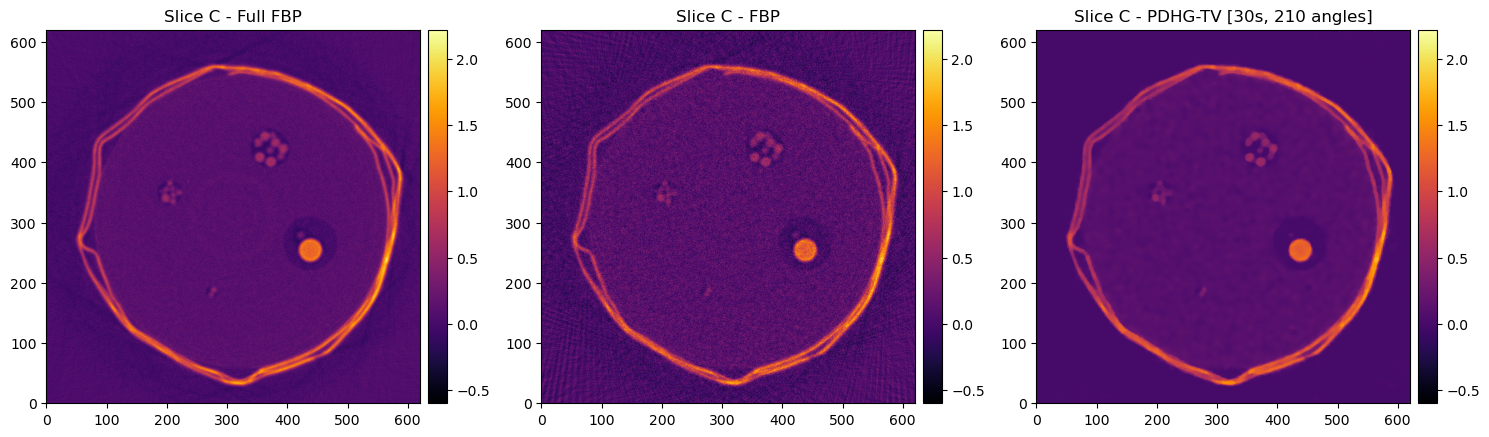

In [32]:
images_by_slice = {}
titles_by_slice = {}

for i, slice_label in enumerate(['A', 'B', 'C']):
    PDHG_titles = [f"Slice {slice_label} - PDHG-TV [30s, 210 angles]"]
    PDHG_results = [PDHG_nn_algos[alpha][i].solution]
    fbp_results = [sliced_recon_dict['FBP [30s, 210 angles]'][i]] 
    fbp_titles = [f"Slice {slice_label} - FBP"]

    images = []
    titles = []
    full_fbp = sliced_recon_dict['FBP [1 min, 840 angles]'][i]
    for PDHG_img, PDHG_title, fbp_img, fbp_title in zip(PDHG_results, PDHG_titles, fbp_results, fbp_titles):
        images.extend([full_fbp, fbp_img, PDHG_img])
        titles.extend([f"Slice {slice_label} - Full FBP", fbp_title, PDHG_title])


    vmin = np.min([img.array.min() for img in images])
    vmax = np.max([img.array.max() for img in images])

    show2D([x.array for x in images], title=titles, cmap='inferno', fix_range=(vmin, vmax), num_cols=3)

    images_by_slice[slice_label] = images
    titles_by_slice[slice_label] = titles

In [33]:
PDHG_results = [PDHG_nn_algos[alpha][i].solution]

sliced_recon_dict[f'PDHG [30s, 210 angles]'] = [PDHG_nn_algos[alpha][i].solution for i in range(len(PDHG_nn_algos[alpha]))]


### Evaluation of PDHG-TV Result with Line profiles and Metrics

We'll be looking at ROIs relating to rods in the cylinder, which we'll refer to with numbered labels as shown in this image:

<img src="images/cylinder_regions.png" width=800 align="center">

#### Contrast to Noise Ratio

In this section we will focus on slice B and evaluate the Contrast to Noise Ratio between the rods and the aluminium cylinder.

For each rod in slice B we first create an ROI which includes the rod and some aluminium cylinder background.

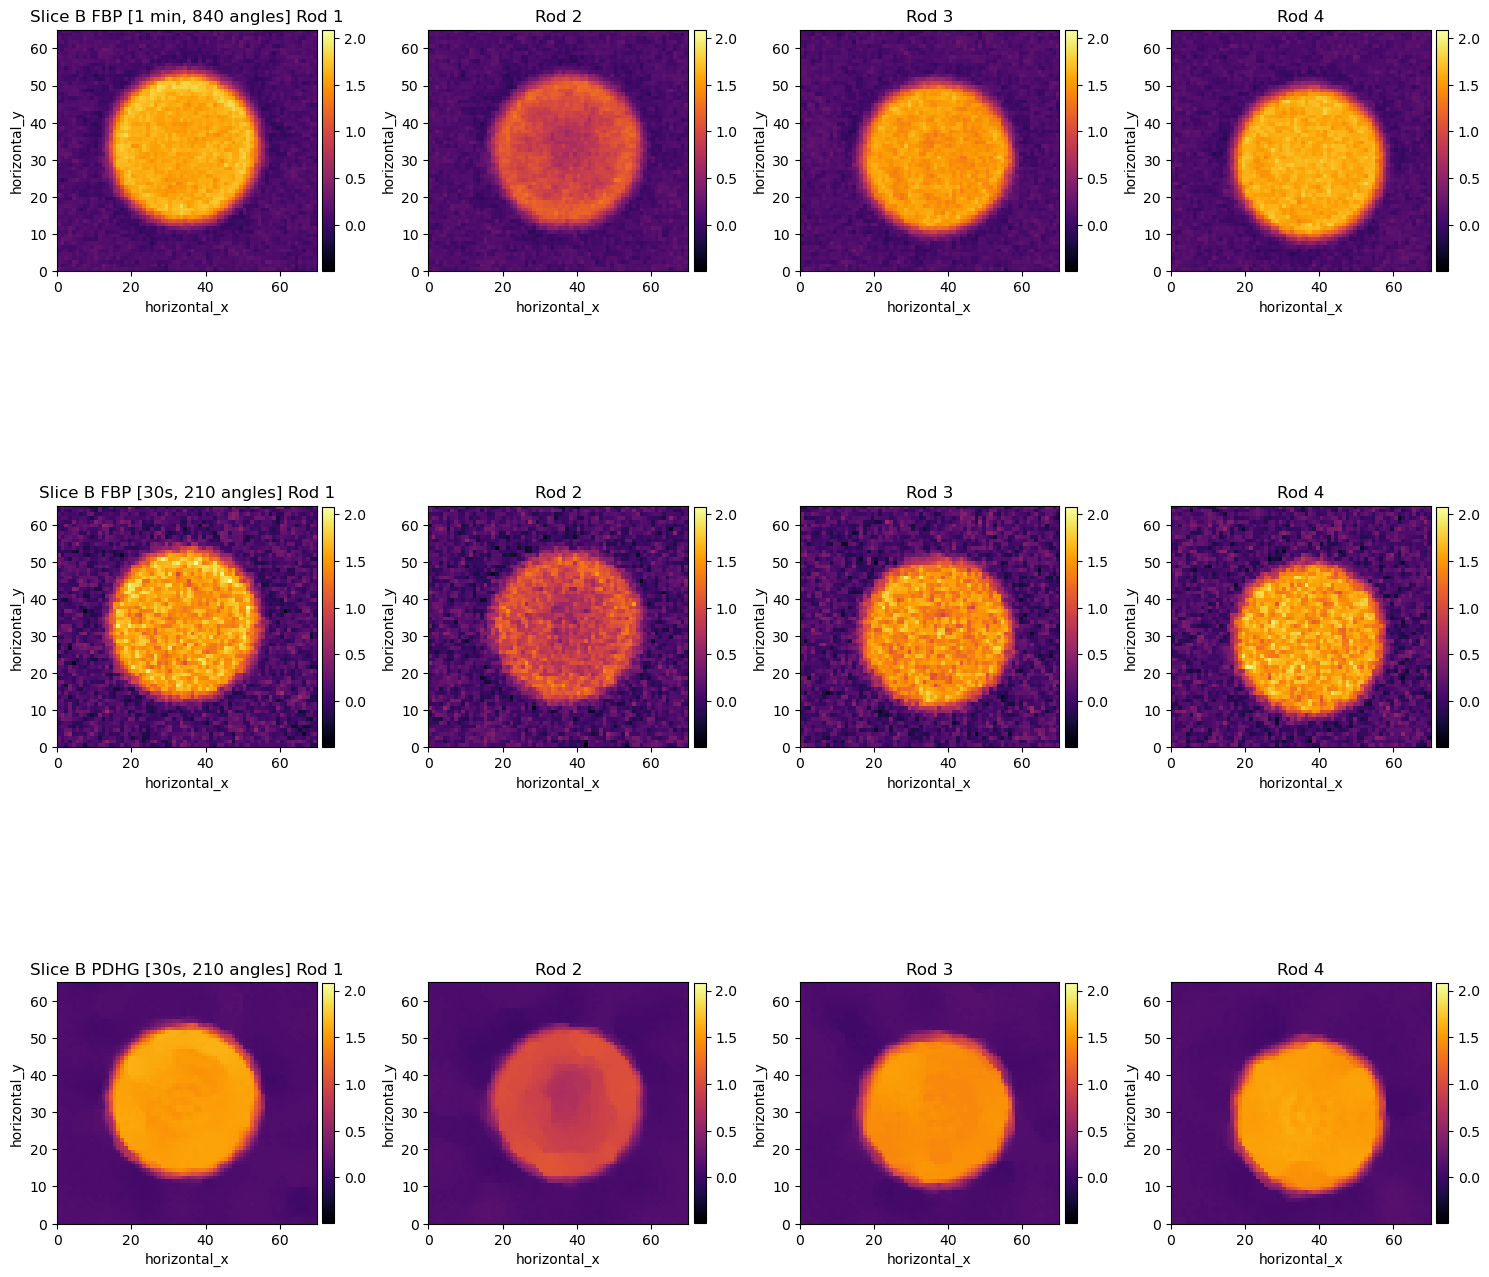

In [34]:
from utils.alum_cyl import crop_rod_B, get_slice_b_outer_rois

slice_B_data = get_slice_b_outer_rois(sliced_recon_dict)

all_rods_B = [rod for entry in slice_B_data.values() for rod in entry["rods"]]
all_labels_B = [label for entry in slice_B_data.values() for label in entry["labels"]]
min = np.min([np.min(r) for r in all_rods_B])
max = np.max([np.max(r) for r in all_rods_B])

show2D(all_rods_B,title=all_labels_B, num_cols=4, cmap="inferno", fix_range=(min, max));

One way we could examine the contrast is using a line profile through this ROI. We display this for rod 1:

In [35]:
labels = list(sliced_recon_dict.keys())

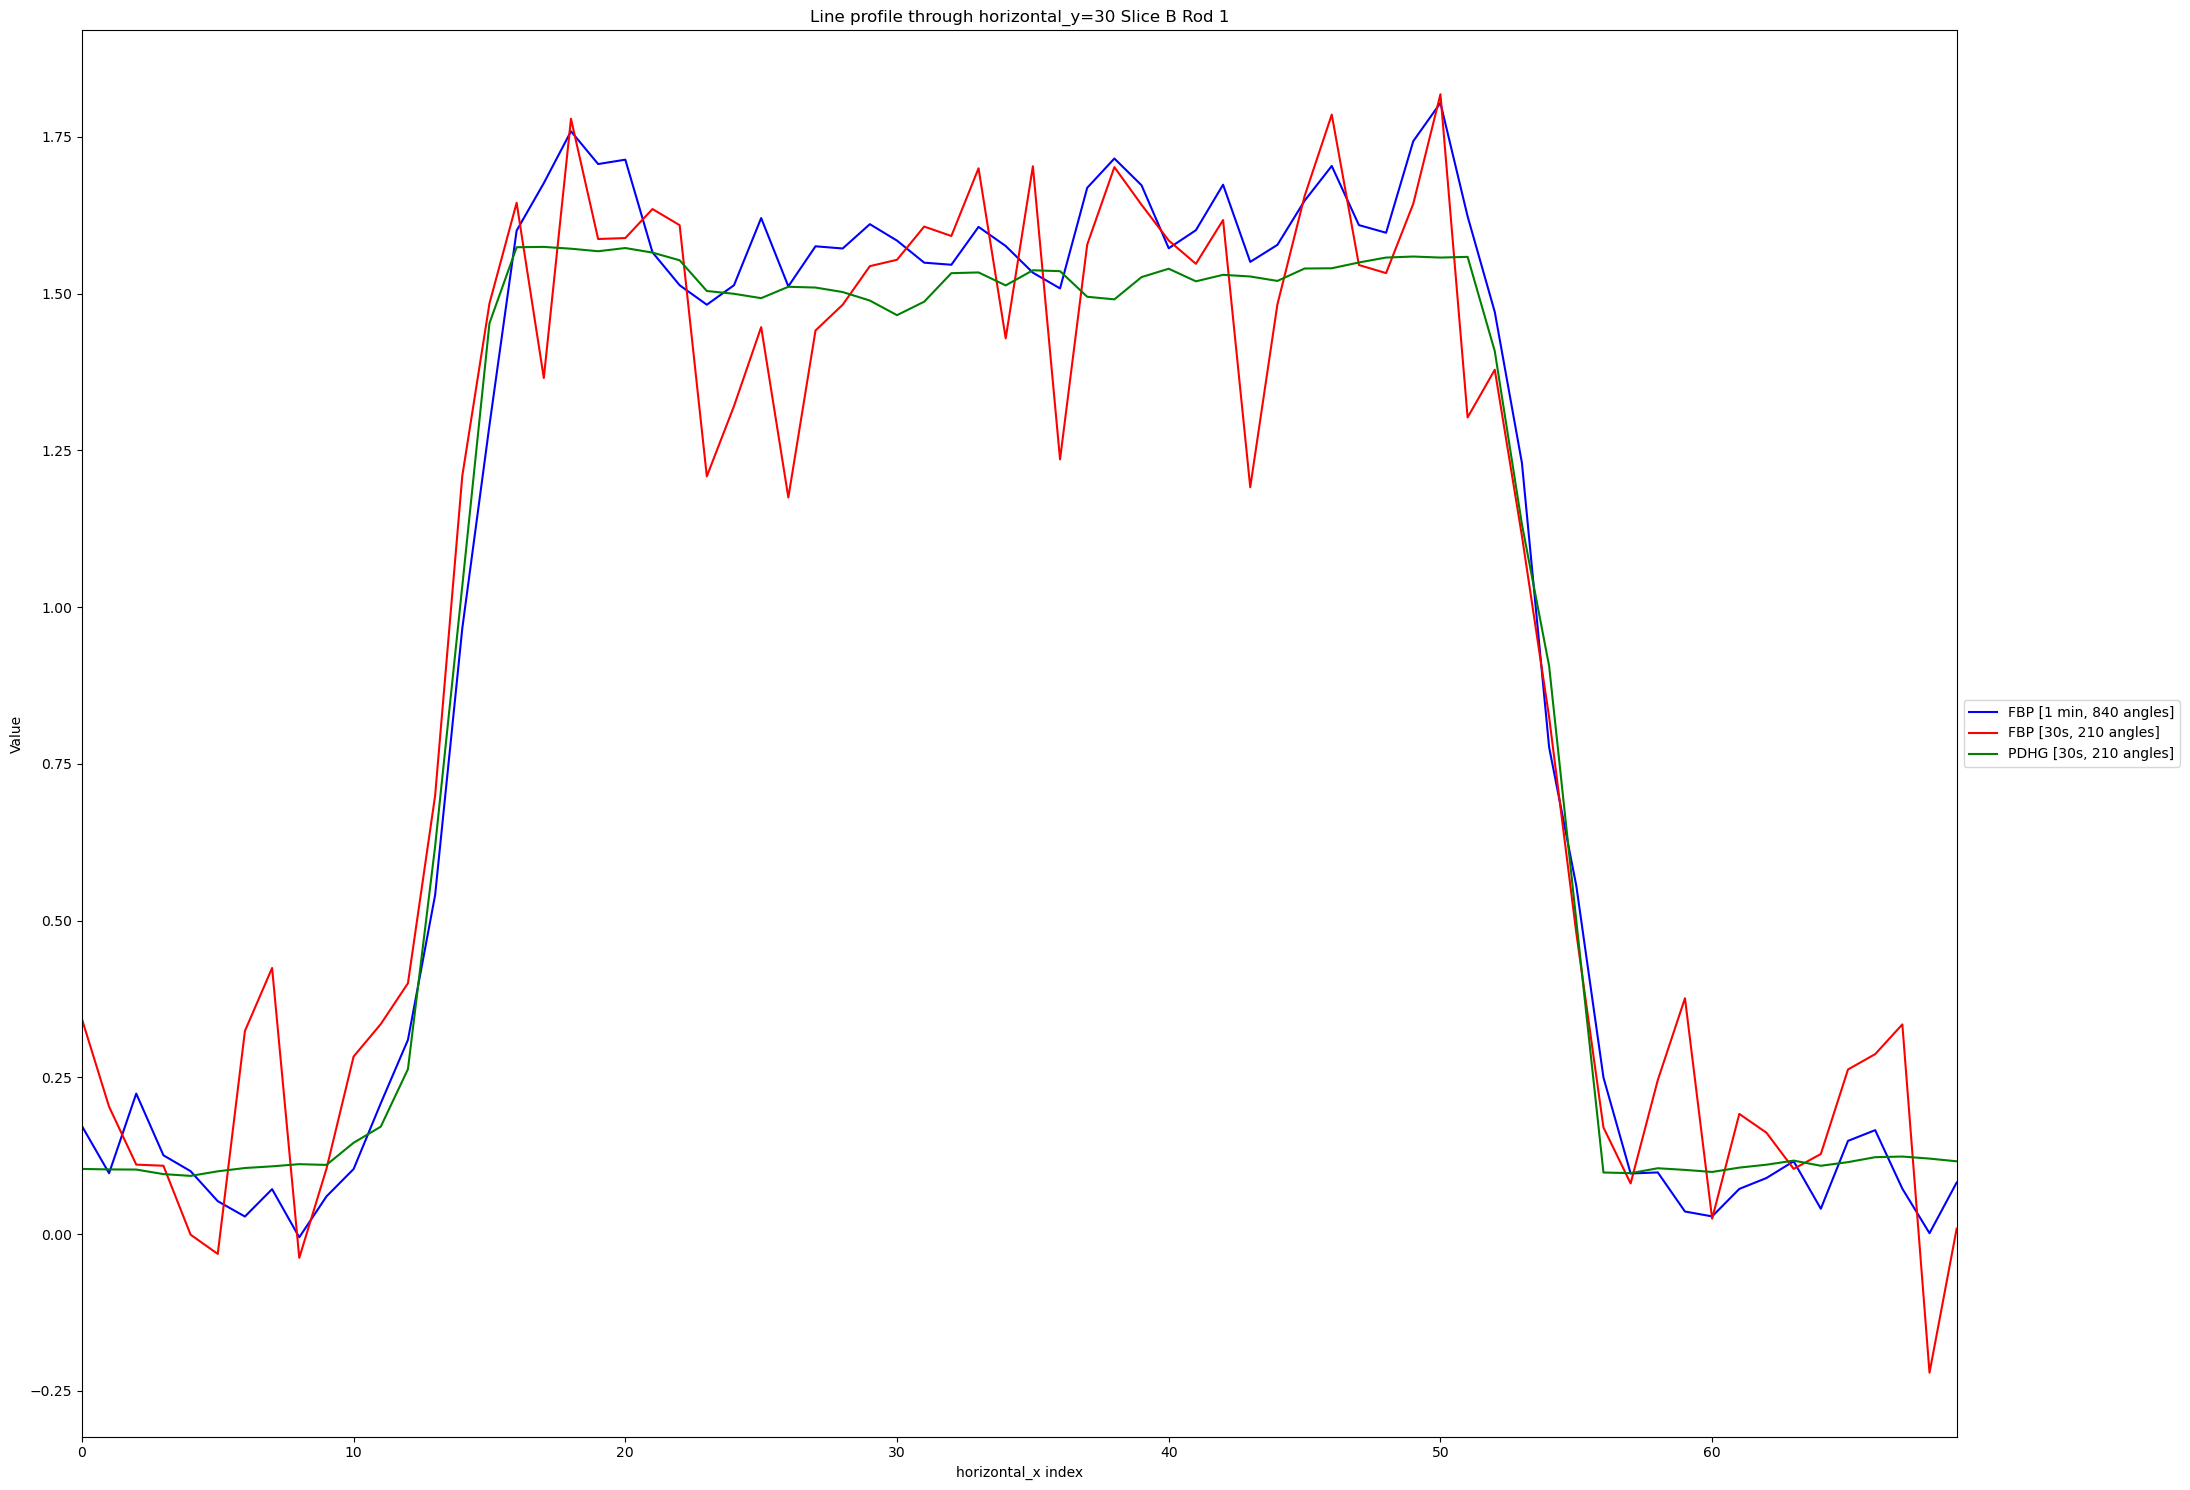

In [36]:
linenumy = 30

rods = [slice_B_data[x]["rods"][0] for x in slice_B_data.keys()]

show1D(rods,
        slice_list=[('horizontal_y',linenumy)],
        title='Line profile through horizontal_y=30 Slice B Rod 1',
        dataset_labels=[str(s) for s in slice_B_data.keys()],
        line_colours=['blue','red','green','orange', 'purple', 'cyan', 'grey'],
        line_styles=['solid']*7,
        size=(22, 15))

We see the noise has been reduced but so has the signal level.

Next we create ROIs with only the material inside each rod, plus an additional ROI of the aluminium cylinder - 'background'.

In [37]:
def get_slice_b_inner_rois(sliced_recon_dict):
    slice_B_data = get_slice_b_outer_rois(sliced_recon_dict)
    data_labels = [ x for x in slice_B_data.keys()]

    for data_label in data_labels:
        slice_B_data[data_label]['rods_inner'] = []
        for i in range(4):
            data = slice_B_data[data_label]["rods"][i]
            roi_img = Slicer(roi={'horizontal_x': (25,45), 'horizontal_y': (25,45)})(data)
            slice_B_data[data_label]['rods_inner'].append(roi_img)
    for data_label in data_labels:
        rec = sliced_recon_dict[data_label][1]
        bkg = Slicer(roi = {'horizontal_x': (300, 320), 'horizontal_y': (400, 420)})(rec)
        label = "Aluminium Cylinder"
        slice_B_data[data_label]["rods_inner"].append(bkg)
        slice_B_data[data_label]["labels"].append(label)


    return slice_B_data

In [38]:
slice_B_data = get_slice_b_inner_rois(sliced_recon_dict)

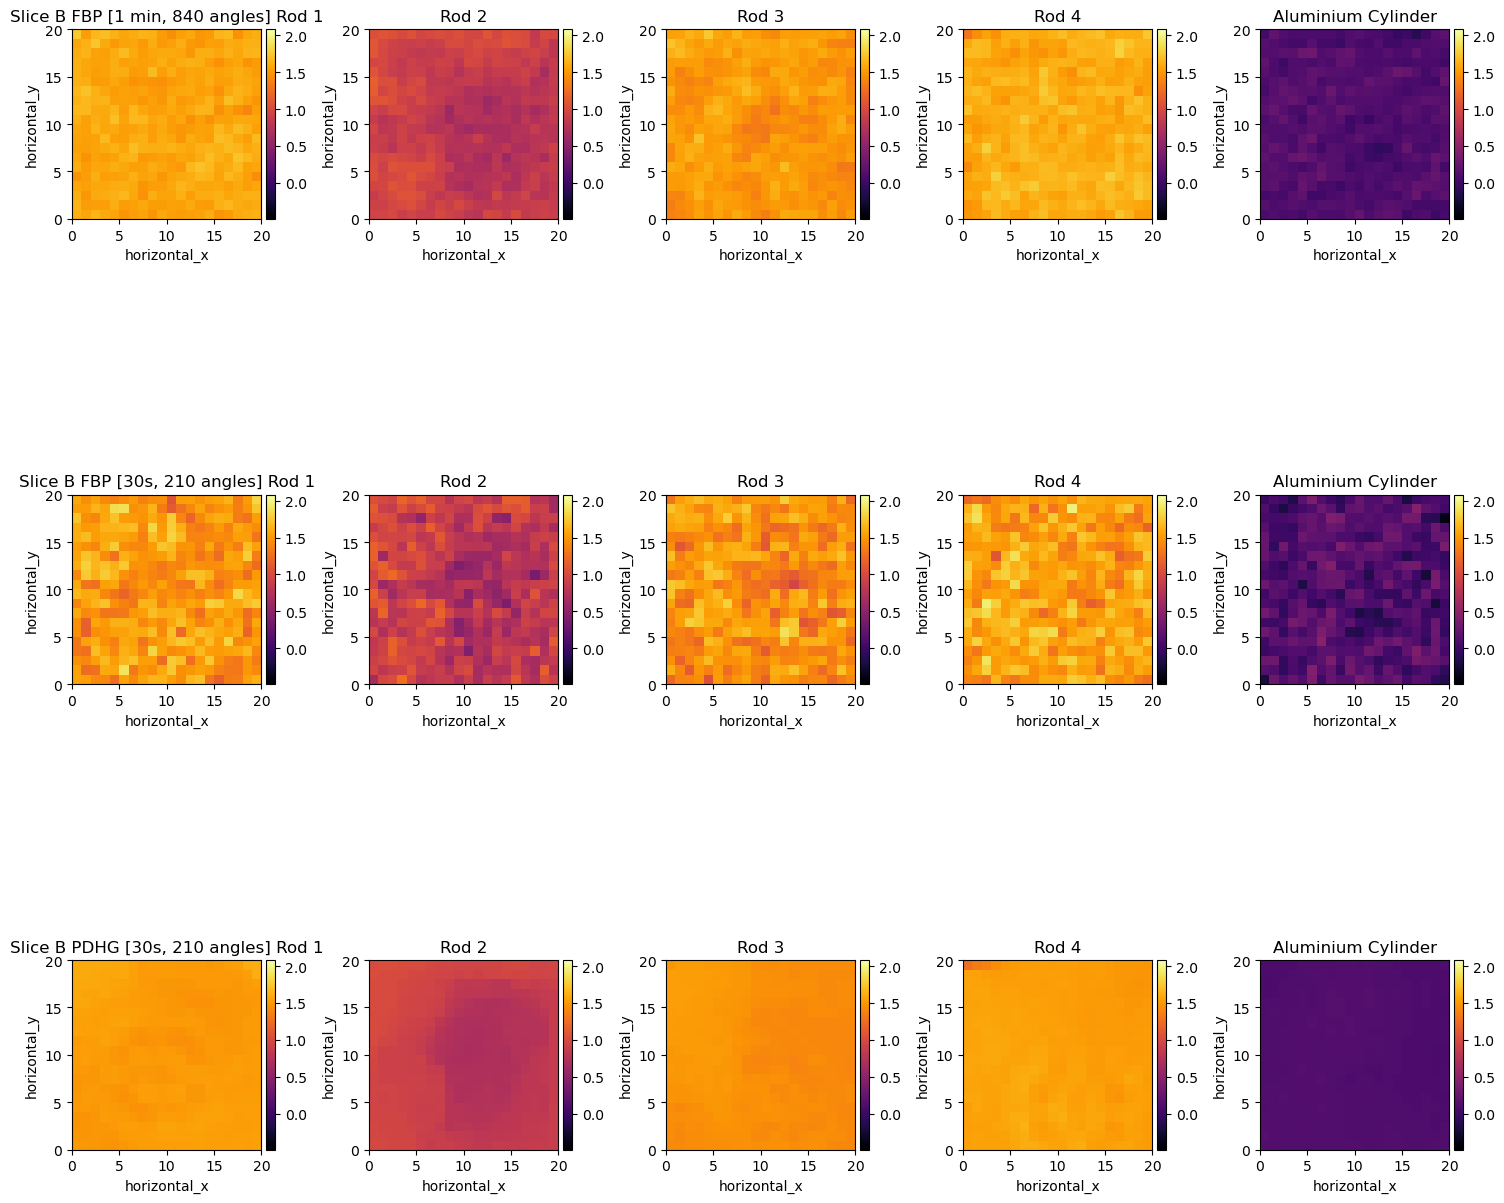

In [39]:
#To show all regions:
show2D([item for sublist in [slice_B_data[x]['rods_inner'] for x in labels] for item in sublist], 
       [item for sublist in [slice_B_data[x]['labels'] for x in labels] for item in sublist],
       fix_range=(min,max), cmap='inferno', num_cols=5)

##### Contrast to Noise Ratio (CNR)
This metric assesses the contrast between the background and the ROI.
&nbsp;

Method:
&nbsp;

$$
\text{CNR} = \frac{\text{Mean of ROI} - \text{Mean of Background}}{\text{Standard Deviation of Background}}
$$
&nbsp;

We will compare an ROI within each rod with an ROI in the aluminium cylinder - 'background', in slice B.

In [40]:
from utils.metrics import calculate_cnr

In [41]:
data_labels = [ x for x in slice_B_data.keys()]
for data_label in data_labels:
    slice_B_data[data_label]['cnrs'] = []
    for i in range(4):
        data = slice_B_data[data_label]["rods_inner"][i]
        bkg_data = slice_B_data[data_label]["rods_inner"][4]
        slice_B_data[data_label]['cnrs'].append(calculate_cnr(data, bkg_data))

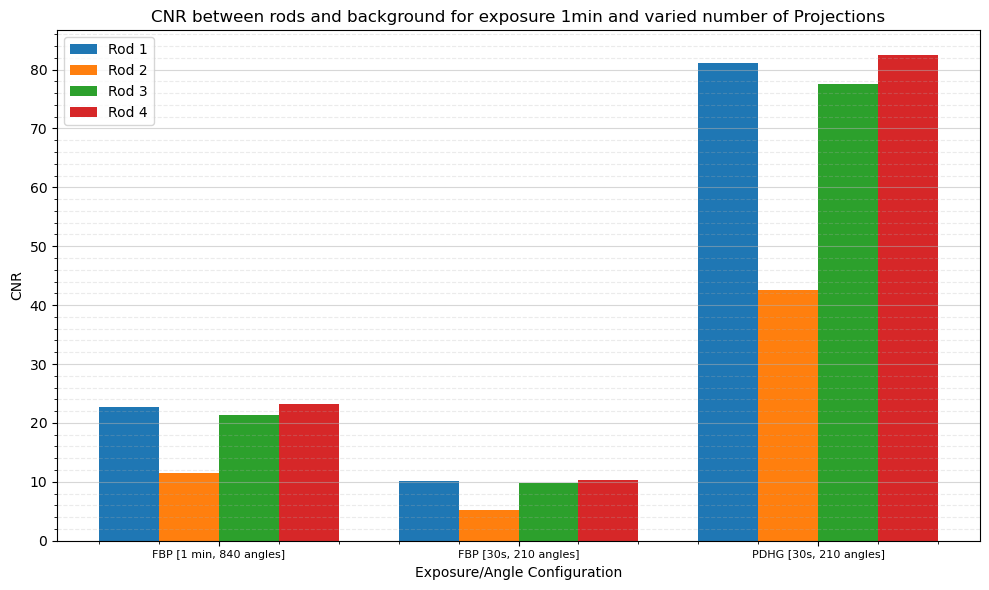

In [42]:
x = np.arange(len(labels))  # x locations for the groups

width = 0.2  # bar width

plt.figure(figsize=(10, 6))

for i in range(4):
    cnrs = [slice_B_data[x_label]['cnrs'][i] for x_label in list(slice_B_data.keys())]
    plt.bar(x + i * width - 1.5*width, cnrs, width, label=f'Rod {i+1}')

plt.xticks(x, labels, fontsize=8)
plt.xlabel('Exposure/Angle Configuration')
plt.ylabel('CNR')
plt.title('CNR between rods and background for exposure 1min and varied number of Projections')
plt.legend()
plt.tight_layout()
plt.minorticks_on()
plt.grid(axis='y', which='major', linestyle='-', alpha=0.5)
plt.grid(axis='y', which='minor', linestyle='--', alpha=0.25)
plt.show()


### Signal to Noise Ratio (SNR)
This is the ratio of signal compared to noise in the region. 
&nbsp;

Method:
&nbsp;

$$
\text{SNR} = \frac{\text{Mean of ROI}}{\text{Standard Deviation of ROI}}
$$
&nbsp;

We will be using the Slice B dataset to apply SNR of different angles/exposures through the cylinder background and the four rods.


In [43]:
from utils.metrics import calculate_snr
from utils.alum_cyl import apply_plot_settings

data_labels = [ x for x in slice_B_data.keys()]

for data_label in data_labels:
    slice_B_data[data_label]['snrs'] = []
    for i in range(5):
        data = slice_B_data[data_label]["rods_inner"][i]
        slice_B_data[data_label]['snrs'].append(calculate_snr(data))

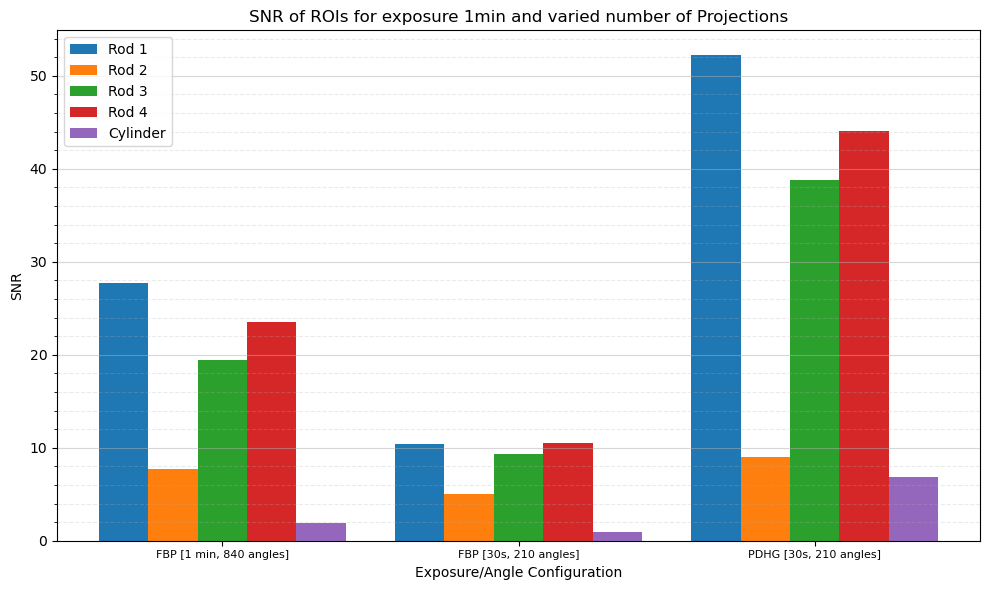

In [44]:
x = np.arange(len(labels))  # x locations for the groups

width = 1/6  # bar width

plt.figure(figsize=(10, 6))

for i in range(5):
    snrs = [slice_B_data[x]['snrs'][i] for x in list(slice_B_data.keys())]
    #plt.plot(labels, snrs, marker='o', label=f'SNR of Rod {i+1}' if i<4 else 'SNR of Cylinder')
    plt.bar(x + i * width - 2*width, snrs, width, label=f'Rod {i+1}' if i<4 else 'Cylinder')

plt.xticks(x, labels, fontsize=8)
plt.xlabel('Exposure/Angle Configuration')
plt.ylabel('SNR')
plt.title('SNR of ROIs for exposure 1min and varied number of Projections')
apply_plot_settings()
plt.show()


But what is the balance between the signal and the noise? Let's take a look at the signal values:

In [45]:
data_labels = [ x for x in slice_B_data.keys()]

for data_label in data_labels:
    slice_B_data[data_label]['signal_mean'] = []
    slice_B_data[data_label]['noise_std'] = []
    for i in range(5):
        data = slice_B_data[data_label]["rods_inner"][i]
        slice_B_data[data_label]['signal_mean'].append(np.mean(data))
        slice_B_data[data_label]['noise_std'].append(np.std(data.array))

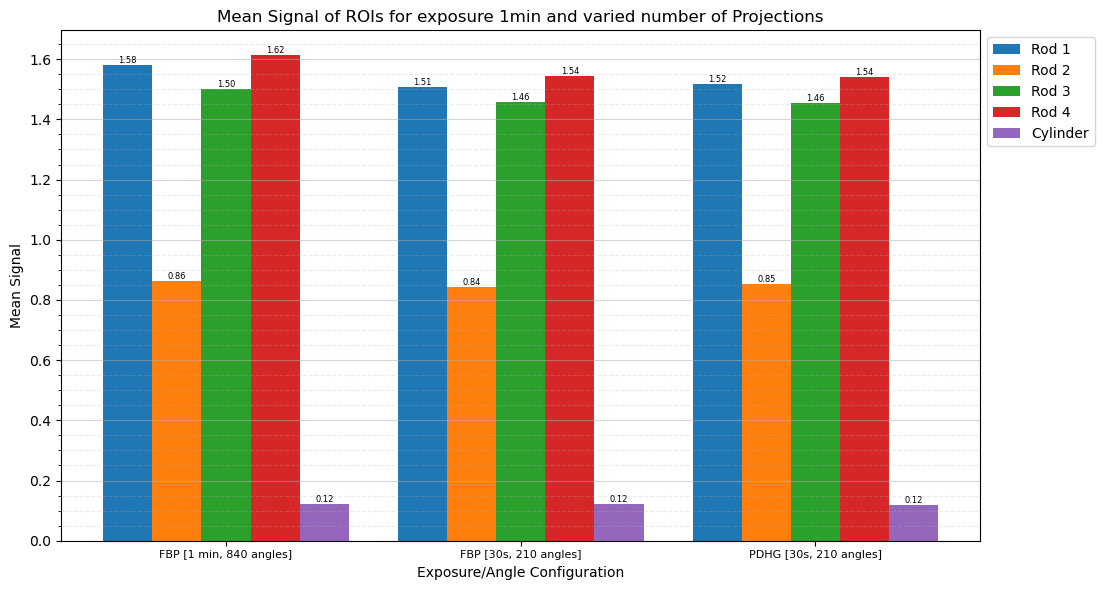

In [46]:
x = np.arange(len(labels)) # x locations for the groups

width = 1/6  # bar width

plt.figure(figsize=(10, 6))

for i in range(5):
    signal_mean = [slice_B_data[x]['signal_mean'][i] for x in list(slice_B_data.keys())]
    plt.bar(x + i * width - 2*width, signal_mean, width, label=f'Rod {i+1}' if i<4 else 'Cylinder')
    # show values on bars:
    for j in range(len(signal_mean)):
        plt.text(x[j] + i * width - 2*width, signal_mean[j], f'{signal_mean[j]:.2f}', ha='center', va='bottom', fontsize=6)

plt.xticks(x, labels[0:4], fontsize=8)
plt.xlabel('Exposure/Angle Configuration')
plt.ylabel('Mean Signal')
plt.title('Mean Signal of ROIs for exposure 1min and varied number of Projections')
apply_plot_settings()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

This shows the PDHG-TV reconstruction has not made the mean signal any worse than the FBP of the dataset

The reason we have a large SNR for the PDHG-TV result is because it has smoothed out the noise so much.

### L2Norm Error (L2N-E)
This metric assess the difference in pixel values between a reconstruction and the ground truth.
&nbsp;

Method:
&nbsp;

$$
\text{L2N-E} = \frac{\| \text{Recon} - \text{Ground Truth} \|_2}{\| \text{Ground Truth} \|_2}
$$
&nbsp;

We will be applying this metric on datasets of Slices A, B and C to compare the L2N-E of different angles/exposures with the ground truth.

In [47]:
from utils.metrics import calculate_L2Norm_error
slice_indices = {'A': 0, 'B': 1, 'C': 2}
ground_truths = {k: sliced_recon_dict['FBP [1 min, 840 angles]'][v] for k, v in slice_indices.items()}


l2_errors = {k: [] for k in slice_indices.keys()}


for recs in sliced_recon_dict.values():
    for slice_key, idx in slice_indices.items():
        l2_errors[slice_key].append(
            calculate_L2Norm_error(ground_truths[slice_key], recs[idx])
        )



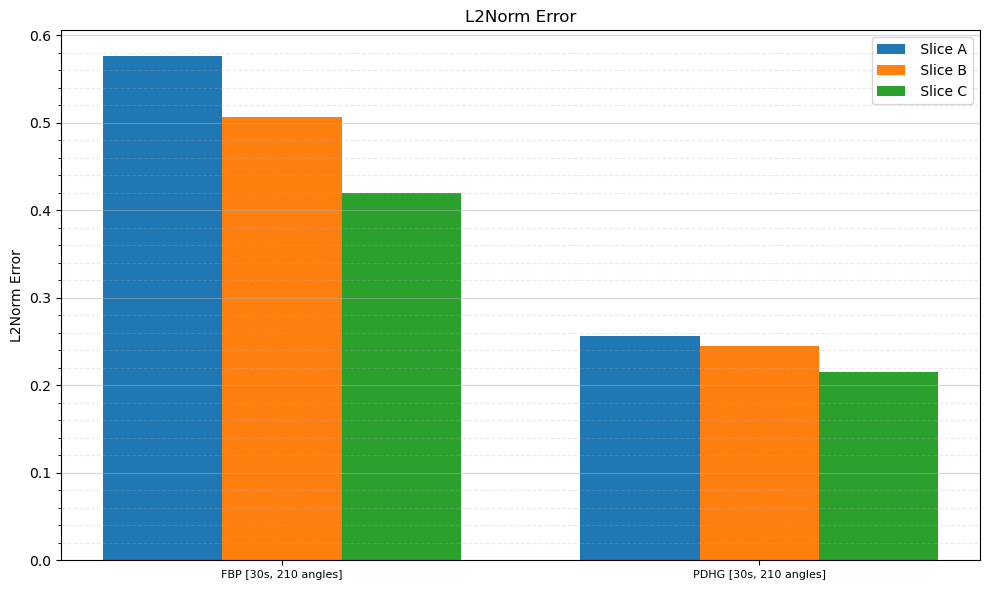

In [48]:
x = np.arange(len(labels[1:]))  # x locations for the groups

width = 0.25

plt.figure(figsize=(10, 6))

i=0
for slice_key, errors in l2_errors.items():
    plt.bar(x+ i * width - width, errors[1:], width, label=f' Slice {slice_key}')
    i+=1

plt.xticks(x, labels[1:], fontsize=8)
plt.ylabel('L2Norm Error')
plt.title('L2Norm Error')
apply_plot_settings()
plt.show()


This section takes three different ROI from the three slices and applies the L2Norm Error metric. This is done to study the behaviour of the metric with respect to object size.


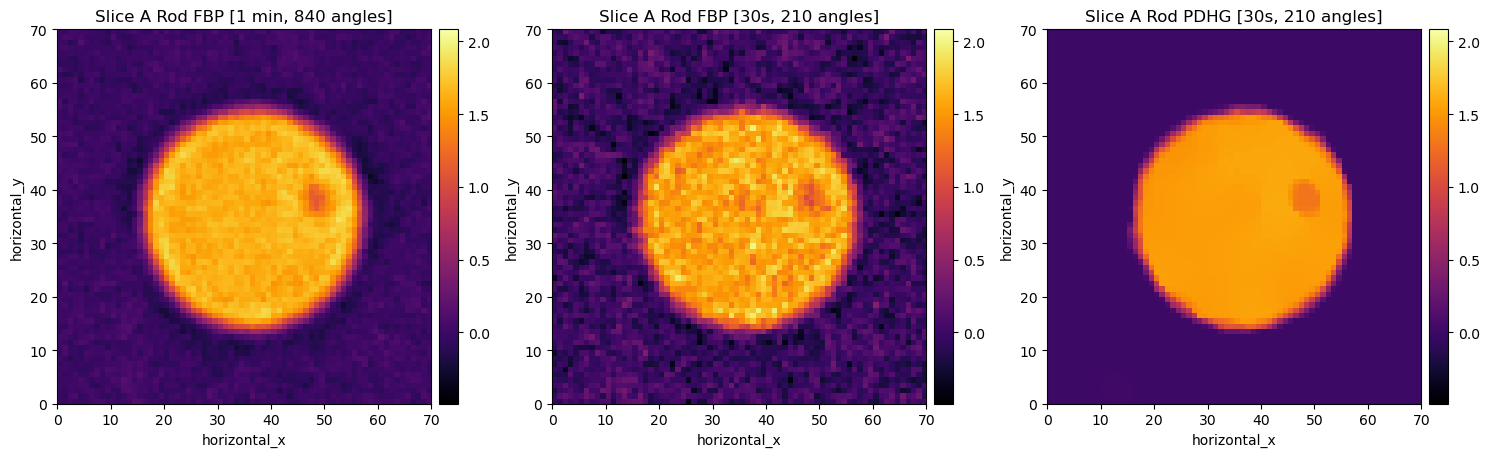

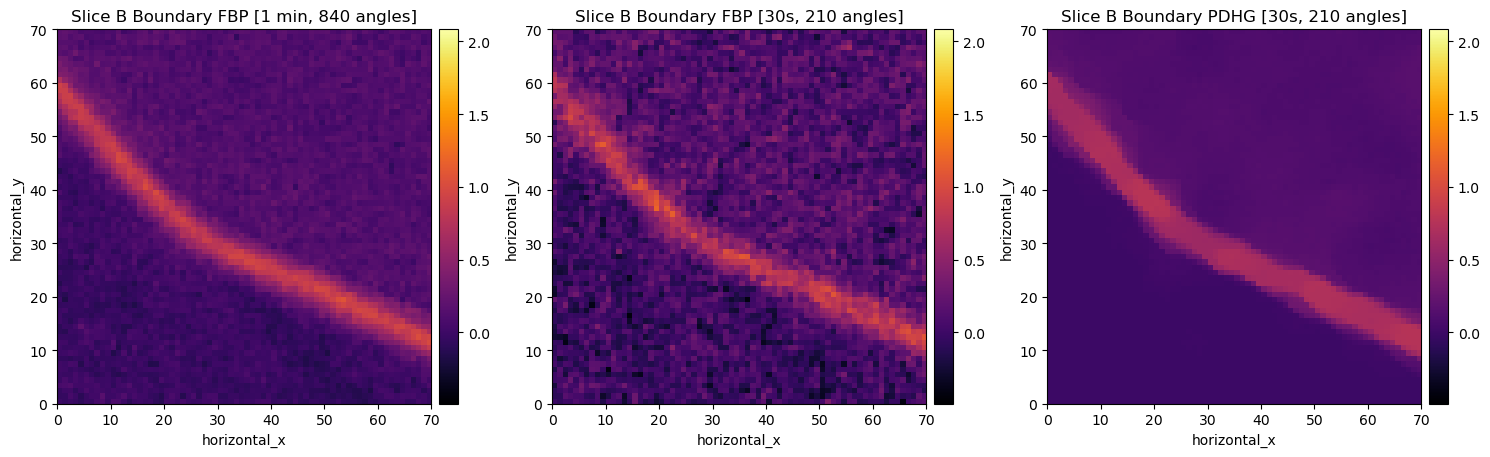

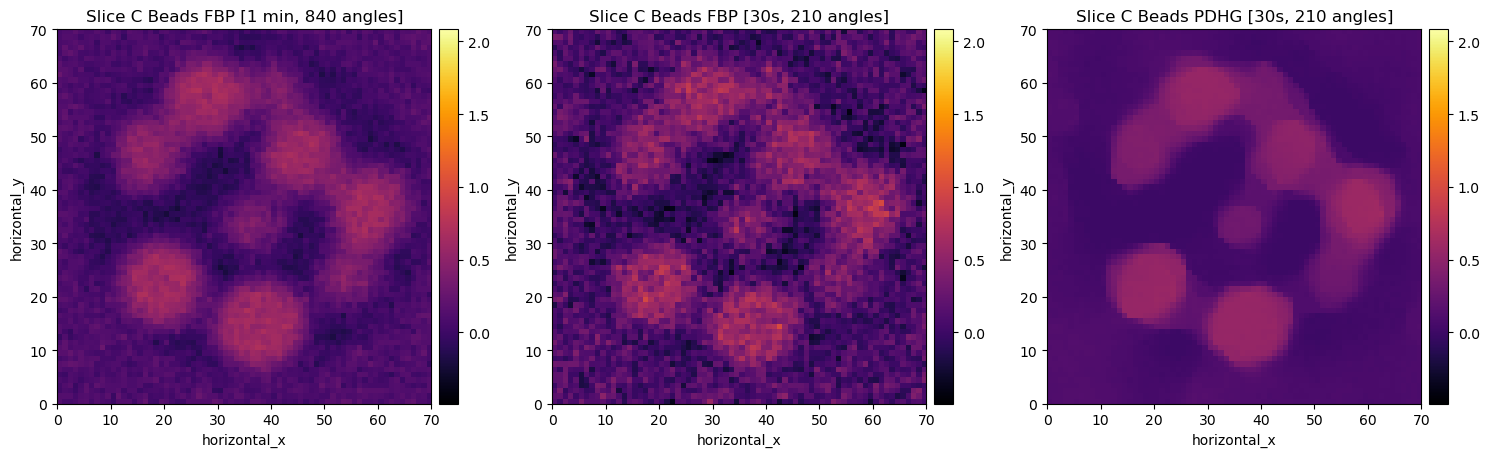

In [49]:
slicer_rod = Slicer(roi={'horizontal_x': (182, 252), 'horizontal_y': (285, 355)})
slicer_boundary = Slicer(roi={'horizontal_x': (160, 230), 'horizontal_y': (60, 130)})
slicer_beads = Slicer(roi={'horizontal_x': (335, 405), 'horizontal_y': (385, 455)})


slice_A_data,  slice_C_data = {}, {}

for key in data_labels:
    slice_A_data[key] = {"L2NormROI": slicer_rod(sliced_recon_dict[key][0])}
    slice_B_data[key]["L2NormROI"] =  slicer_boundary(sliced_recon_dict[key][1])
    slice_C_data[key] = {"L2NormROI": slicer_beads(sliced_recon_dict[key][2])}

# --- Select ground truth samples ---
ground_truth_a = slice_A_data["FBP [1 min, 840 angles]"]["L2NormROI"]
ground_truth_b = slice_B_data["FBP [1 min, 840 angles]"]["L2NormROI"]
ground_truth_c = slice_C_data["FBP [1 min, 840 angles]"]["L2NormROI"]


show2D([slice_A_data[key]["L2NormROI"] for key in data_labels], title=[f'Slice A Rod {key}' for key in data_labels], fix_range=(min,max), cmap='inferno', num_cols=4);
show2D([slice_B_data[key]["L2NormROI"] for key in data_labels], title=[f'Slice B Boundary {key}' for key in data_labels], fix_range=(min,max), cmap='inferno', num_cols=4);
show2D([slice_C_data[key]["L2NormROI"] for key in data_labels], title=[f'Slice C Beads {key}' for key in data_labels], fix_range=(min,max), cmap='inferno', num_cols=4);

Let's also take a look at the line profile through the rod, at a row where we can see the imperfection in the rod - it's interesting to see how well this is maintained with reduced data:

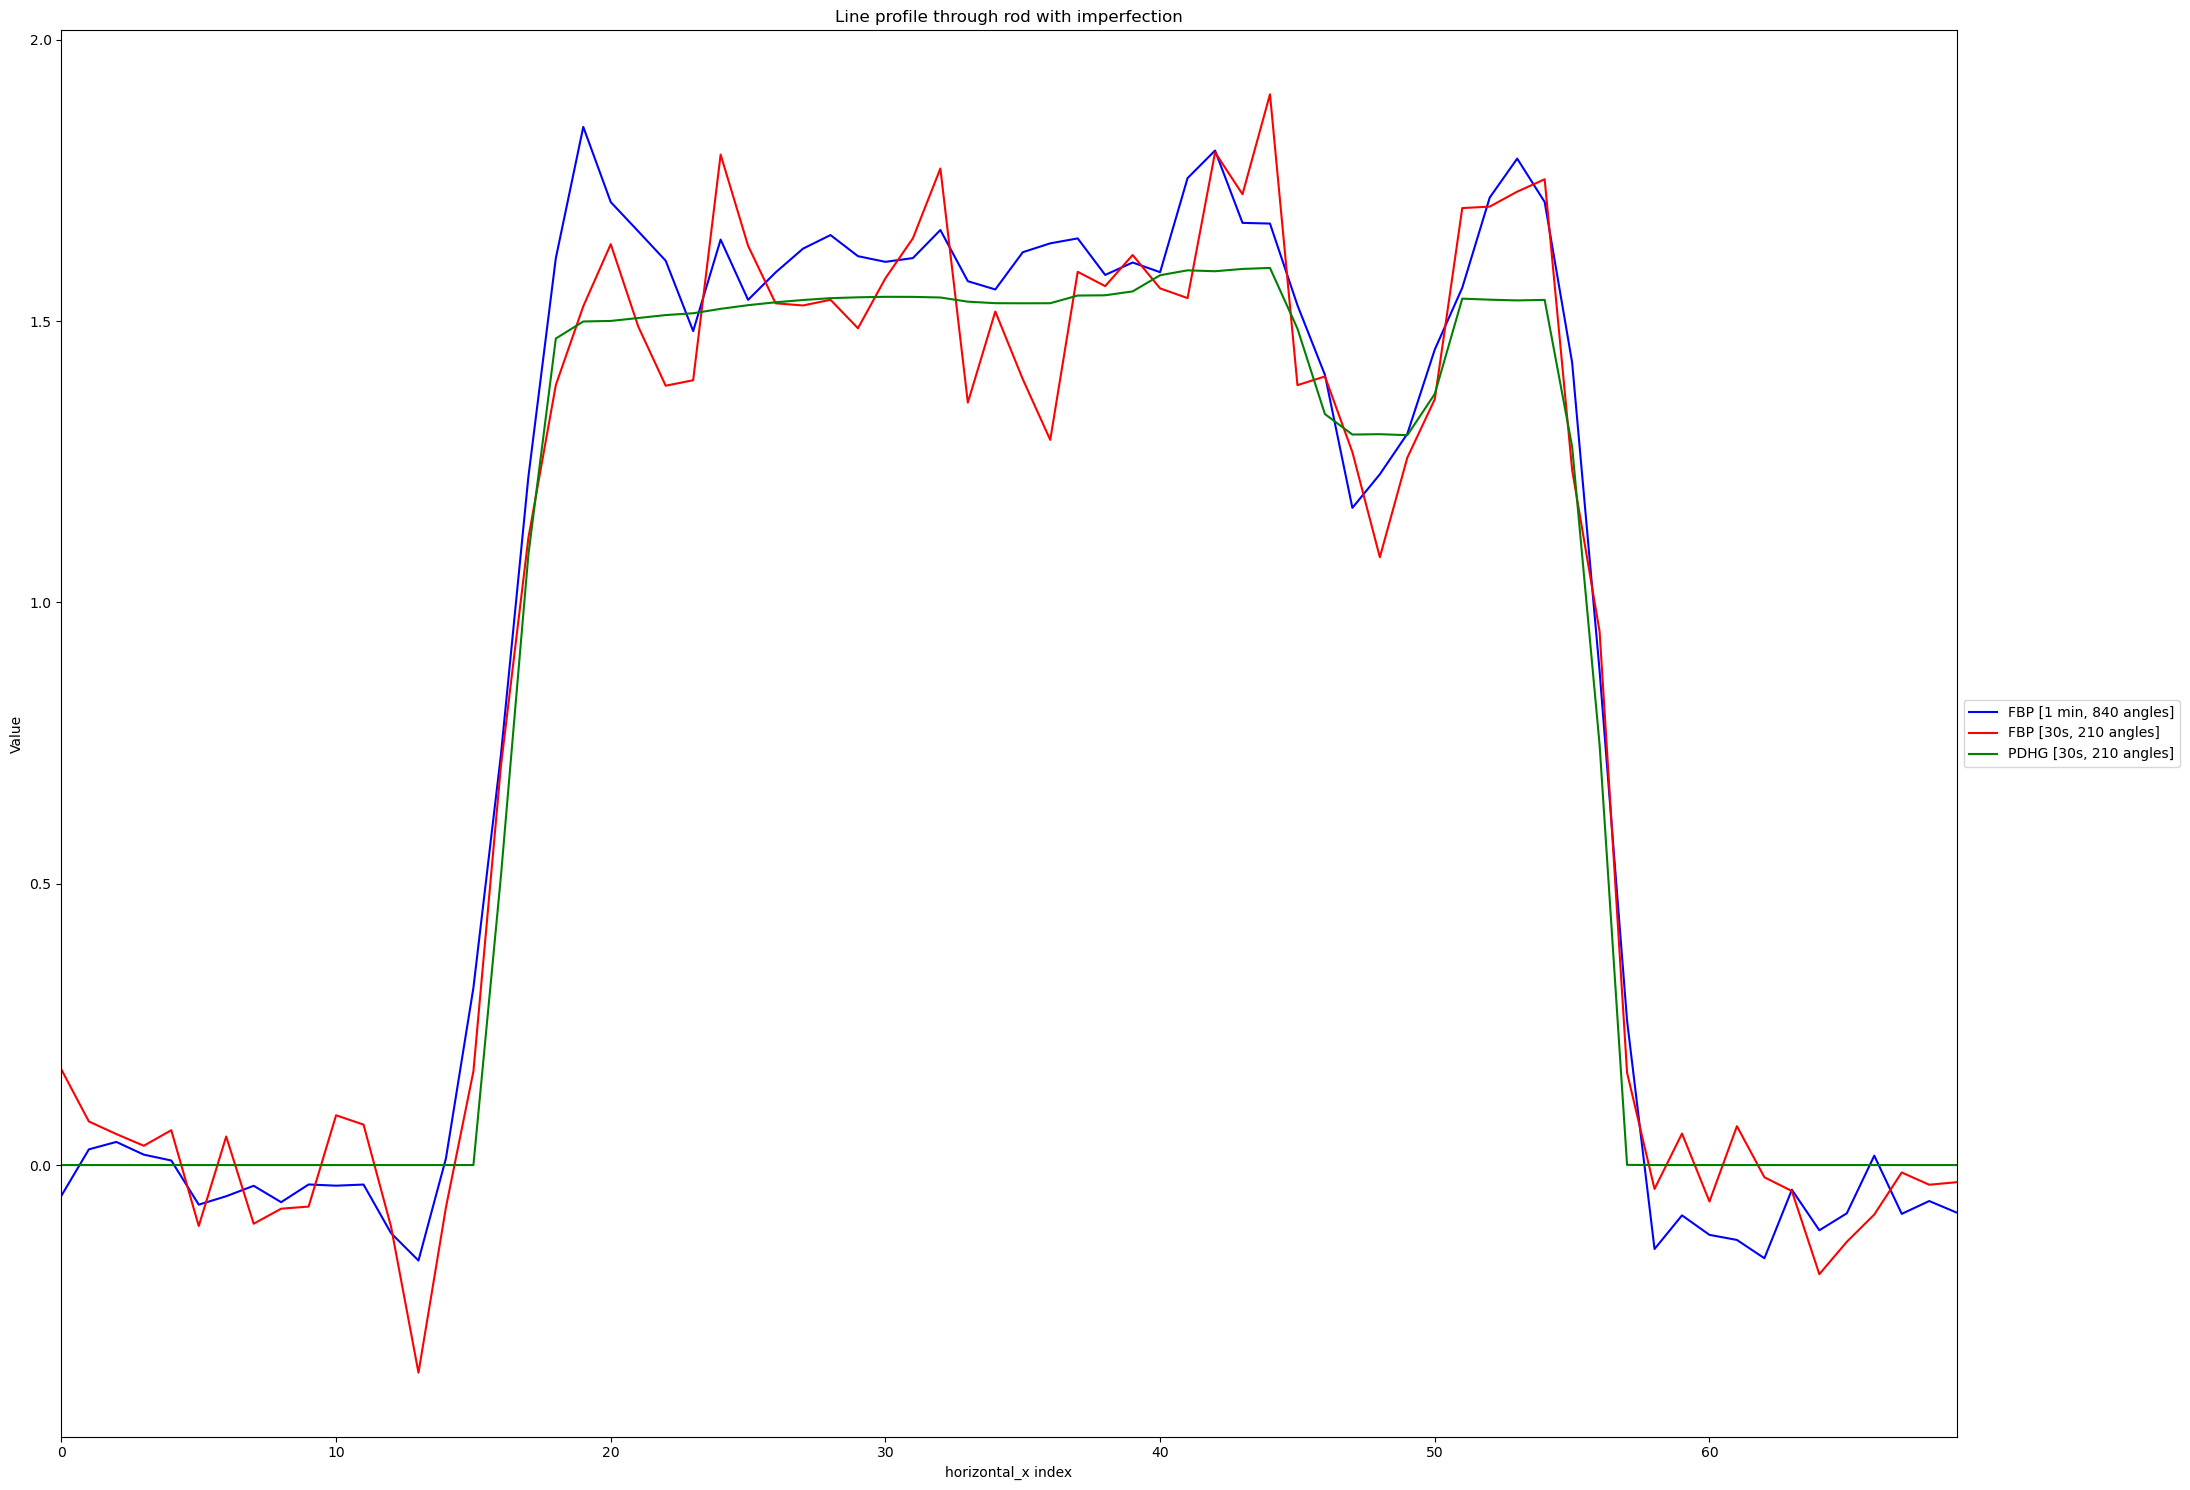

In [50]:
linenumy = 39

rods = [slice_A_data[x]["L2NormROI"] for x in slice_B_data.keys()]

show1D(rods,
        slice_list=[('horizontal_y',linenumy)],
        title='Line profile through rod with imperfection',
        dataset_labels=labels,
        line_colours=['blue','red','green','orange', 'purple', 'cyan', 'grey'],
        line_styles=['solid']*7,
        size=(22, 15))

In [51]:

for key in data_labels:
    slice_A_data[key]['L2Norm'] = calculate_L2Norm_error(ground_truth_a, slice_A_data[key]['L2NormROI'], apply_mask=False)
    slice_B_data[key]['L2Norm'] = calculate_L2Norm_error(ground_truth_b, slice_B_data[key]['L2NormROI'], apply_mask=False)
    slice_C_data[key]['L2Norm'] = calculate_L2Norm_error(ground_truth_c, slice_C_data[key]['L2NormROI'], apply_mask=False)


slice_A = [slice_A_data[key]['L2Norm'] for key in data_labels]
slice_B = [slice_B_data[key]['L2Norm'] for key in data_labels]
slice_C = [slice_C_data[key]['L2Norm'] for key in data_labels]

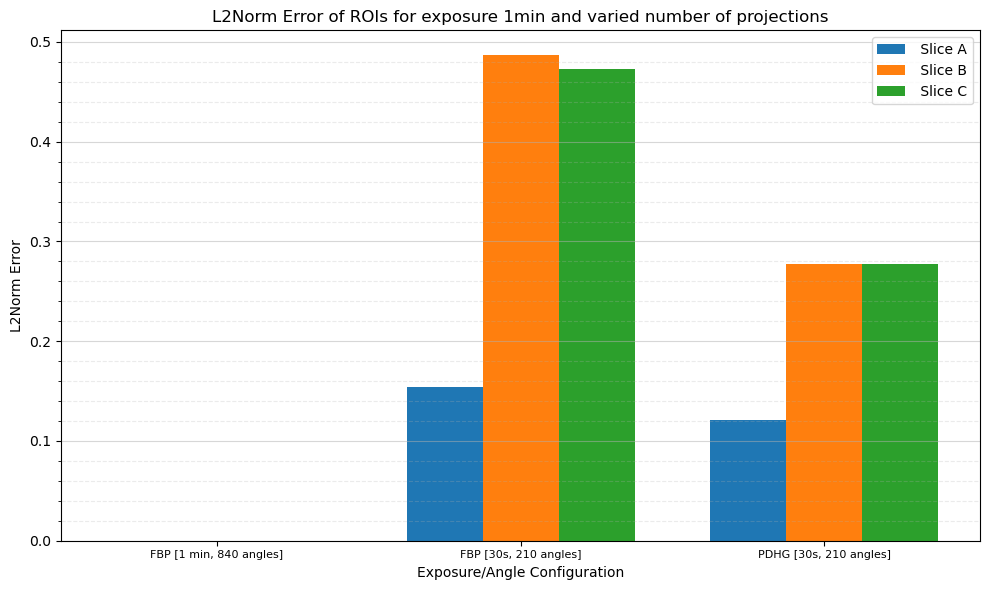

In [52]:
x = np.arange(len(labels))

width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, slice_A, width, label=f' Slice A')
plt.bar(x, slice_B, width, label=f' Slice B')
plt.bar(x + width, slice_C, width, label=f' Slice C')

plt.xticks(x, labels, fontsize=8)
plt.xlabel('Exposure/Angle Configuration')
plt.ylabel('L2Norm Error')
plt.title('L2Norm Error of ROIs for exposure 1min and varied number of projections')
apply_plot_settings()
plt.show()



In [53]:
from cil.io import NEXUSDataWriter
output_folder = "outputs"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
if not os.path.exists(os.path.join(output_folder, "cylinder/pdhg/")):
    os.makedirs(os.path.join(output_folder, "cylinder/pdhg/"))

for i in range(3):
        rec = PDHG_nn_algos[alpha][i].solution
        file_name = f'Slice_{i}.nxs'
        nexus_writer = NEXUSDataWriter(data=rec, file_name=os.path.join(output_folder, "cylinder", "pdhg", file_name))
        nexus_writer.write()

## Conclusion

This notebook has demonstrated how PDHG-TV can be used to smooth noise in a reduced reconstruction.
We see the rods and Aluminium cylinder look nice and smooth, with reasonable boundaries enforced, but in the 'boundary' and 'beads' ROIs we see oversmoothing with noise being promoted to material.
A smaller alpha value could potentially help with this. For future investigations it would be beneficial to experiment with alpha with FISTA-TV. In the Golden Angle notebooks we showcase how FISTA typically converges much faster which makes it a lot easier to tune the alpha parameter. Additionally we showed we did not reach convergence with PDHG-TV in this notebook, so being able to converge with FISTA would also provide improvement.